In [1]:
import os
os.chdir("../../../../..")

In [2]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from dscribe.kernels import REMatchKernel
from loguru import logger
from umap import UMAP

from src.non_euclidean import Wasserstein
from src.datasets import QM9Dataset

In [3]:
qm9 = QM9Dataset(limit=80_000, descriptors=["soap"])
df = qm9.load()

2026-05-29 09:30:07.344 | INFO     | src.datasets:_load_full_qm9_df:817 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-05-29 09:30:07.730 | INFO     | src.datasets:_sample_qm9_df:1000 - QM9 sampling complete: strategy=stratified, requested_limit=80000, returned_rows=80000, sampling on columns=['num_atoms', 'gap'].
2026-05-29 09:30:07.732 | INFO     | src.datasets:_add_requested_descriptors:202 - Applying requested QM9 descriptors to sampled dataframe (rows=80000).
2026-05-29 09:30:07.811 | INFO     | src.features:compute_soap_outputs:395 - Computing SOAP (rcut=6.0, nmax=8, lmax=6, normalize=True)...
2026-05-29 09:32:12.274 | SUCCESS  | src.datasets:add_soap:1193 - Added SOAP embeddings and matrices.
2026-05-29 09:32:12.352 | INFO     | src.datasets:_add_requested_descriptors:213 - Added descriptor column(s): ['soap_embedding', 'soap_matrix']
2026-05-29 09:32:12.448 | INFO     | src.datasets:_load_with_descriptor_filter:857 - QM9 descriptor null-filtering 

In [4]:
def rematch_kernel_dist_matrix(df, metric="linear", alpha=0.1, tol=1e-3):

    soap_matrices = df["soap_matrix"].to_list()

    cleaned = []

    normalized = False
    for i, x in enumerate(soap_matrices):
        x = np.asarray(x, dtype=np.float64)

        # shape check
        if x.ndim != 2:
            raise ValueError(f"SOAP matrix {i} is not 2D: shape={x.shape}")

        # finite check
        if not np.isfinite(x).all():
            raise ValueError(f"Non-finite values in SOAP matrix {i}")

        # ----------------------------
        # Check if already normalized
        # ----------------------------
        norms = np.linalg.norm(x, axis=1)

        already_normalized = np.all(np.abs(norms - 1.0) < tol)

        if already_normalized:
            x_norm = x
            normalized = True
            cleaned = soap_matrices
            logger.info("Descriptor is already normalized")
            if normalized:
                break
        else:
            x_norm = x / (norms[:, None] + 1e-12)
        

        # final sanity check
        if not np.isfinite(x_norm).all():
            raise ValueError(f"NaN/inf after normalization in matrix {i}")

        cleaned.append(x_norm)

    # ----------------------------
    # REMatch kernel
    # ----------------------------
    kernel = REMatchKernel(
        metric=metric,
        alpha=alpha
    )

    print("Computing REMatch kernel matrix...")
    K = kernel.create(cleaned)

    if not np.isfinite(K).all():
        raise ValueError("Kernel matrix contains NaN or inf")

    # ----------------------------
    # Distance conversion
    # ----------------------------
    diag = np.diag(K)
    dist_sq = diag[:, None] + diag[None, :] - 2.0 * K

    dist_sq = np.clip(dist_sq, 0.0, None)
    D = np.sqrt(dist_sq)

    np.fill_diagonal(D, 0.0)
    D = (D + D.T) / 2.0

    return D

# Experiment 1 isomers seperation experiment

In [13]:
formula_counts = df.group_by("formula").len("count").sort("count", descending=True)
print(formula_counts.head(10))

shape: (10, 2)
┌─────────┬───────┐
│ formula ┆ count │
│ ---     ┆ ---   │
│ str     ┆ u32   │
╞═════════╪═══════╡
│ C7H10O2 ┆ 3575  │
│ C8H12O  ┆ 2890  │
│ C7H12O2 ┆ 2870  │
│ C6H9NO2 ┆ 2482  │
│ C7H11NO ┆ 1963  │
│ C8H14O  ┆ 1924  │
│ C7H9NO  ┆ 1874  │
│ C6H7NO2 ┆ 1743  │
│ C8H10O  ┆ 1716  │
│ C7H8O2  ┆ 1680  │
└─────────┴───────┘


In [32]:
import logging
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from umap import UMAP
from sklearn.metrics import silhouette_score
from rdkit import Chem
import ot  # Python Optimal Transport (POT)
from dscribe.kernels import REMatchKernel

# Setup basic logging config
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger("StrainExperiment")

# =============================================================================
# 1. RDKIT TOPOLOGY FILTERING
# =============================================================================
def categorize_pure_carbocycle(smiles: str) -> str:
    """
    Parses a SMILES string. 
    Returns '3-ring' or '6-ring' ONLY if the ring is made entirely of Carbon.
    Rejects heterocycles (rings with O, N, F, etc.) and acyclic structures.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None or "O" in smiles or "N" in smiles:
        return "Other"
    
    ring_info = mol.GetRingInfo().AtomRings()
    if not ring_info:
        return "Acyclic"
        
    for ring in ring_info:
        for atom_idx in ring:
            atom = mol.GetAtomWithIdx(atom_idx)
            if atom.GetAtomicNum() != 6:
                return "Heterocycle"
                
    sizes = set(len(ring) for ring in ring_info)
    if sizes == {3}:
        return "3-ring"
    elif sizes == {6}:
        return "6-ring"
    else:
        return "Mixed/Other"



# =============================================================================
# 3. METRIC EVALUATION & PUBLICATION GRAPH GENERATION
# =============================================================================
def run_strain_topology_comparison(
    df: pl.DataFrame,
    d_rematch: np.ndarray,
    d_w1: np.ndarray,
    d_w2: np.ndarray,
    label_col: str = "ring_category"
) -> None:
    """Computes topological summary properties and generates the side-by-side UMAP plot."""
    raw_labels = df.get_column(label_col).to_numpy()
    legend_labels = np.where(raw_labels == "3-ring", "Strained (3-Membered)", "Relaxed (6-Membered)")
    unique_classes = np.unique(legend_labels)

    matrices = {
        "REMatch Kernel": d_rematch,
        "Wasserstein ($W_1$)": d_w1,
        "Wasserstein ($W_2$)": d_w2
    }

    metrics_summary = {}

    # Calculate distance metrics properties
    for name, dist_matrix in matrices.items():
        sil = silhouette_score(dist_matrix, legend_labels, metric="precomputed")
        
        intra_dists = []
        for cls in unique_classes:
            idx = np.where(legend_labels == cls)[0]
            sub_matrix = dist_matrix[np.ix_(idx, idx)]
            triu_idx = np.triu_indices(len(idx), k=1)
            intra_dists.append(np.mean(sub_matrix[triu_idx]))
        mean_intra = np.mean(intra_dists)

        idx_strained = np.where(legend_labels == "Strained (3-Membered)")[0]
        idx_relaxed = np.where(legend_labels == "Relaxed (6-Membered)")[0]
        inter_matrix = dist_matrix[np.ix_(idx_strained, idx_relaxed)]
        mean_inter = np.mean(inter_matrix)

        separation_ratio = mean_intra / mean_inter
        metrics_summary[name] = {
            "Silhouette": sil, "Intra-Class": mean_intra, "Inter-Class": mean_inter, "Sep-Ratio": separation_ratio
        }

    print("\n" + "="*85)
    print(f"{'Framework / Metric':<30} | {'Intra-Class (↓)':<15} | {'Inter-Class (↑)':<15} | {'Sep Ratio (↓)':<13} | {'Silhouette (↑)':<12}")
    print("-" * 85)
    for name, m in metrics_summary.items():
        print(f"{name:<30} | {m['Intra-Class']:<15.4f} | {m['Inter-Class']:<15.4f} | {m['Sep-Ratio']:<13.4f} | {m['Silhouette']:<12.4f}")
    print("="*85 + "\n")

    # Generate Plots
    plt.style.use("seaborn-v0_8-whitegrid")
    fig, axes = plt.subplots(1, 3, figsize=(20, 6.5), dpi=300)
    palette = {"Strained (3-Membered)": "#cc5e53", "Relaxed (6-Membered)": "#568bbd"}

    for ax, (name, dist_matrix) in zip(axes, matrices.items()):
        print(f"Computing UMAP projection from precomputed {name} matrix...")
        reducer = UMAP(n_neighbors=5, metric="precomputed", random_state=42)
        umap_coords = reducer.fit_transform(dist_matrix)

        sns.scatterplot(
            x=umap_coords[:, 0], y=umap_coords[:, 1],
            hue=legend_labels, palette=palette, s=90, alpha=0.85,
            edgecolors="#2d3436", linewidths=0.8, ax=ax, zorder=10,
        )

        ax.set_title(name, fontsize=13, fontweight="bold", pad=15)
        ax.set_xlabel("UMAP Dimension 1", fontsize=10, fontweight="medium")
        ax.set_ylabel("UMAP Dimension 2", fontsize=10, fontweight="medium")
        ax.grid(True, linestyle=":", alpha=0.6)
        ax.get_legend().remove()
        sns.despine(ax=ax)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels, title="Ring Topology Mapping", title_fontsize=11, fontsize=10,
        loc="lower center", bbox_to_anchor=(0.5, -0.08), ncol=2,
        frameon=True, facecolor="white", edgecolor="#e2e8f0",
    )

    plt.tight_layout()
    output_filename = "transport_strain_comparison.png"
    plt.savefig(output_filename, format="png", dpi=300, bbox_inches="tight")
    print(f"Saved high-res comparison plot to {output_filename}")
    plt.show()


# =============================================================================
# 4. MAIN PIPELINE EXECUTION
# =============================================================================
def run_pipeline(df_base: pl.DataFrame):
    """
    Executes structural cleaning, unifies balance allocations across matching
    chemical formulas, computes distances, and generates benchmarks.
    """
    # Step A: Perform RDKit classification
    print("Categorizing rings and enforcing pure carbocycles using RDKit...")
    df_classified = df_base.with_columns(
        pl.col("smiles")
        .map_elements(categorize_pure_carbocycle, return_dtype=pl.Utf8)
        .alias("ring_category")
    )

    df_3_rings_all = df_classified.filter(pl.col("ring_category") == "3-ring")
    df_6_rings_all = df_classified.filter(pl.col("ring_category") == "6-ring")

    # Step B: Identify overlapping formula matches
    counts_3 = df_3_rings_all.group_by("formula").len().rename({"len": "count_3"})
    counts_6 = df_6_rings_all.group_by("formula").len().rename({"len": "count_6"})
    formula_overlap = counts_3.join(counts_6, on="formula", how="inner")

    formula_overlap = formula_overlap.with_columns(
        pl.min_horizontal("count_3", "count_6").alias("max_balanced_size")
    ).sort("max_balanced_size", descending=True)

    if formula_overlap.height == 0:
        raise ValueError("No overlapping pure carbocycle formulas found in this dataset subset.")

    # Step C: Extract best formula matches and balance allocations
    best_row = formula_overlap.row(0, named=True)
    best_formula = best_row["formula"]
    max_size = min(best_row["max_balanced_size"], 100)  # Capped for quick loop resolution

    print(f"\nOptimal configuration located: {best_formula}")
    print(f"Sampling balanced sets of size: {max_size}")

    df_3_sampled = df_3_rings_all.filter(pl.col("formula") == best_formula).sample(n=max_size, seed=42)
    df_6_sampled = df_6_rings_all.filter(pl.col("formula") == best_formula).sample(n=max_size, seed=42)
    df_experiment = pl.concat([df_3_sampled, df_6_sampled])

    # Step D: Execute metric transformations
    d_rematch = rematch_kernel_dist_matrix(df_experiment, metric="linear", alpha=0.1)
    wasserstein = Wasserstein()
    d_w1 = wasserstein.distance_matrix(df_experiment, metric='euclidean')
    d_w2 = wasserstein.distance_matrix(df_experiment, metric='sqeuclidean')

    # Step E: Trigger evaluation summary and plotting
    run_strain_topology_comparison(df_experiment, d_rematch, d_w1, d_w2, label_col="ring_category")


Categorizing rings and enforcing pure carbocycles using RDKit...


INFO:StrainExperiment:Descriptor is already normalized



Optimal configuration located: C9H16
Sampling balanced sets of size: 27
Computing REMatch kernel matrix...


2026-05-29 10:05:10.987 | INFO     | src.non_euclidean:_feature_matrices_from_df:332 - Using column: soap_matrix from df
2026-05-29 10:05:11.027 | INFO     | src.non_euclidean:distance_matrix:751 - Computing Wasserstein distance matrix sequentially | Features: soap | Metric: euclidean
Wasserstein distances: 100%|██████████| 54/54 [00:00<00:00, 96.06row/s]
2026-05-29 10:05:11.598 | INFO     | src.non_euclidean:_feature_matrices_from_df:332 - Using column: soap_matrix from df
2026-05-29 10:05:11.645 | INFO     | src.non_euclidean:distance_matrix:751 - Computing Wasserstein distance matrix sequentially | Features: soap | Metric: sqeuclidean
Wasserstein distances: 100%|██████████| 54/54 [00:00<00:00, 108.65row/s]
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavai


Framework / Metric             | Intra-Class (↓) | Inter-Class (↑) | Sep Ratio (↓) | Silhouette (↑)
-------------------------------------------------------------------------------------
REMatch Kernel                 | 0.1423          | 0.1542          | 0.9228        | 0.0768      
Wasserstein ($W_1$)            | 0.2078          | 0.2258          | 0.9206        | 0.0790      
Wasserstein ($W_2$)            | 0.0492          | 0.0558          | 0.8823        | 0.1176      

Computing UMAP projection from precomputed REMatch Kernel matrix...
Computing UMAP projection from precomputed Wasserstein ($W_1$) matrix...


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Computing UMAP projection from precomputed Wasserstein ($W_2$) matrix...
Saved high-res comparison plot to transport_strain_comparison.png


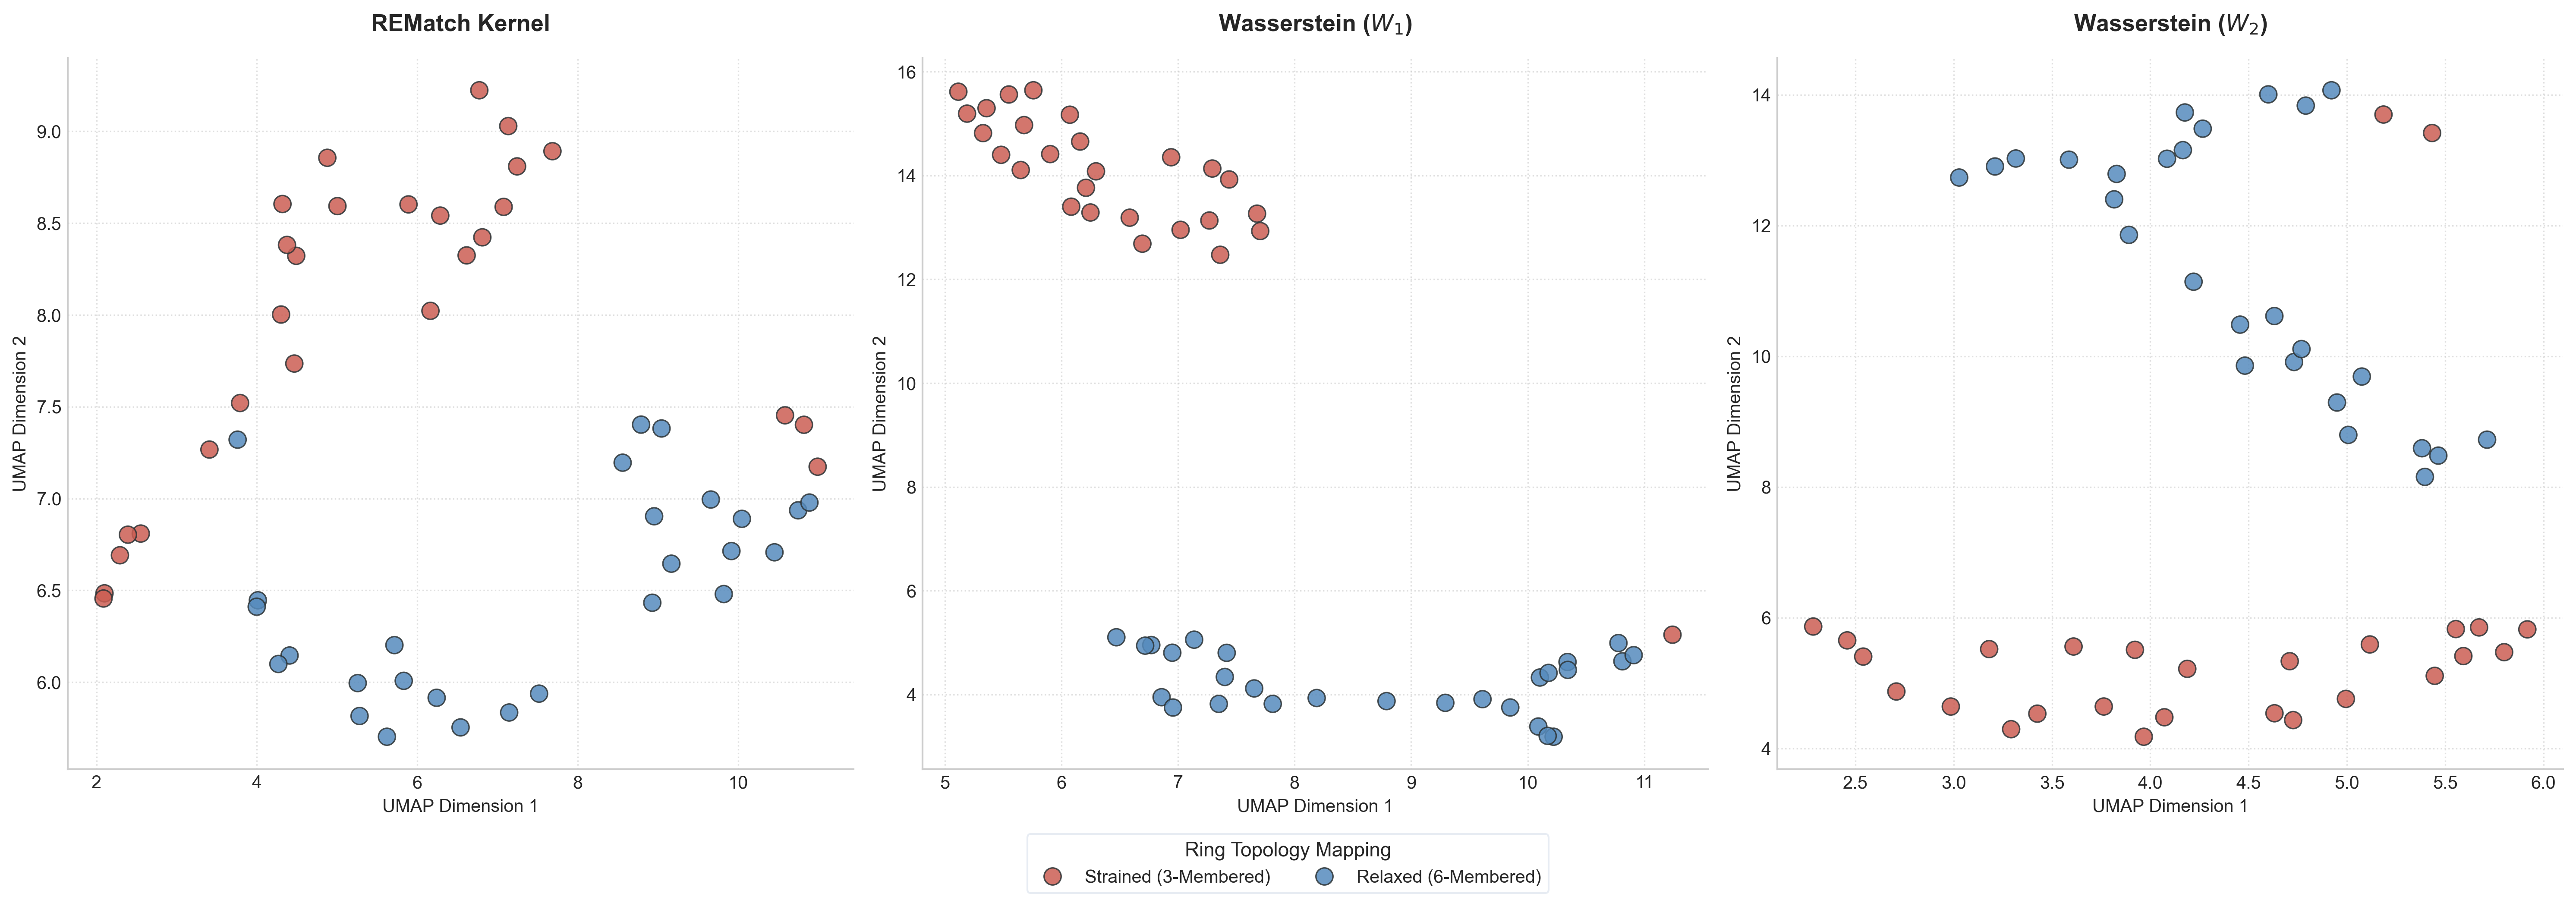

In [33]:
run_pipeline(df)